**BANK CUSTOMER CHURN PREDICTION**
###### - ANANYA PATANKAR


---



In [1]:
#import required libraries
import pandas as pd
import numpy as np
import joblib
import shap
from matplotlib import pyplot as plt
from sklearn.metrics import precision_recall_curve, fbeta_score, classification_report

#load processed datasets and final model
X_train = pd.read_csv('X_train_final.csv')
X_test = pd.read_csv('X_test_final.csv')
y_train = pd.read_csv('y_train_final.csv').squeeze()
y_test = pd.read_csv('y_test_final.csv').squeeze()
lgbm_model = joblib.load('lightgbm.pkl')

**GLOBAL FEATURE IMPORTANCE (SHAP) :**

SHAP (SHapley Additive exPlanations) is used to interpret the LightGBM model's performance. These values show the magnitude and direction of each feature's contribution to individual predictions, creating transparency with respect to the model's decisions.

In [2]:
#initialize SHAP explainer for the tree-based model
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_test)

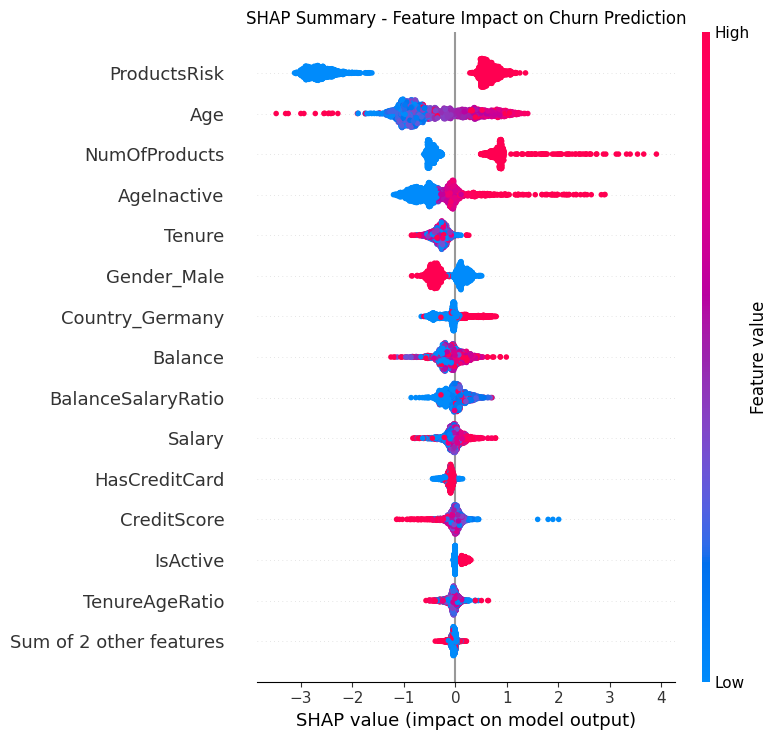

               feature  lgbm_importance  mean_abs_shap
10        ProductsRisk               69       1.564123
1                  Age              543       0.711355
3        NumOfProducts               97       0.678681
6          AgeInactive              215       0.490714
2               Tenure              321       0.293723
15         Gender_Male              132       0.286988
13     Country_Germany              108       0.198931
4              Balance              310       0.189733
7   BalanceSalaryRatio              184       0.155873
5               Salary              288       0.124451


In [3]:
#SHAP beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Summary - Feature Impact on Churn Prediction")
plt.tight_layout()
plt.show()

#compare against LightGBM's built-in feature importance
importance_df = pd.DataFrame({'feature': X_train.columns,
                              'lgbm_importance': lgbm_model.feature_importances_,
                              'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
                              }).sort_values('mean_abs_shap', ascending=False)

print(importance_df.head(10))

Each dot in the beeswarm plot shows one customer. Its horizontal position shows the SHAP value and its color the customer's actual value for the feature (red=high, blue=low). For ProductsRisk, this gives two distinct clusters- the low values (blue) are strongly negative, while the high values (red) are strongly positive.

This is reflected in its overall impact as well. ProductsRisk has the highest mean absolute SHAP value at 1.56, nearly double than that of the next influential feature, i.e. Age (0.71). This is a sharp deviation from LightGBM's built-in importance, which mainly shows split count, not impact. Age is split on 543 times, while ProductsRisk just 69 times, yet it has the largest impact on churn.

Other factors, too, show a similar pattern. NumOfProducts and AgeInactive rank higher in their SHAP impact than their split counts, while Tenure has a higher split count than its SHAP values would suggest.

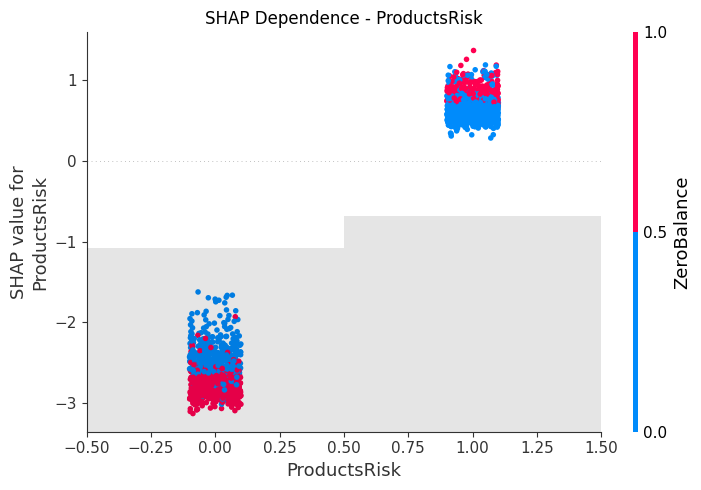

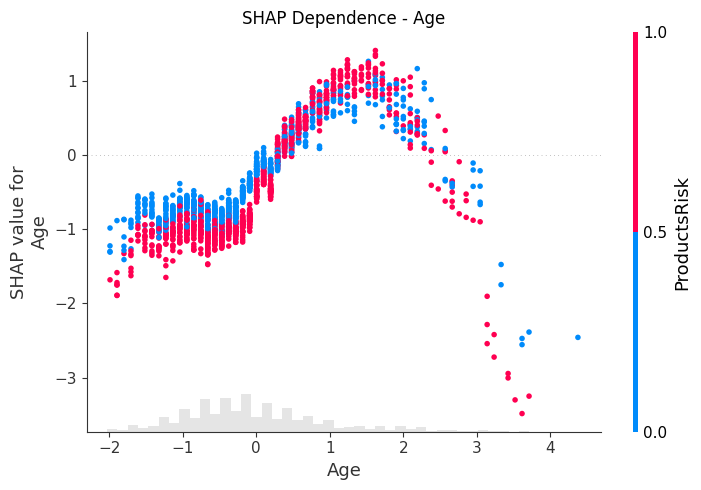

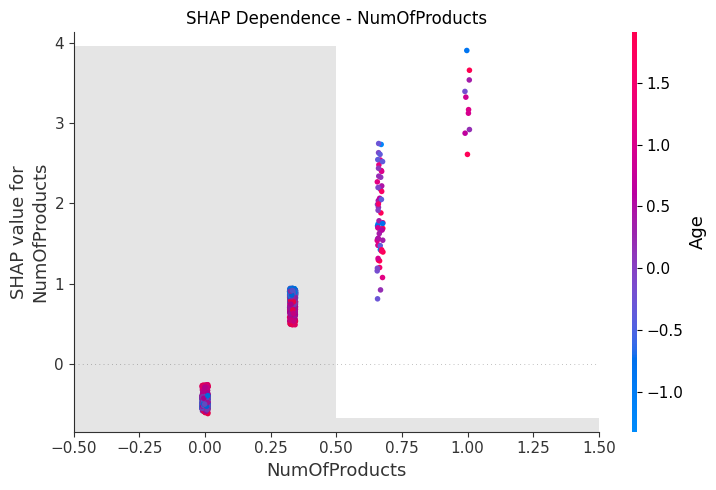

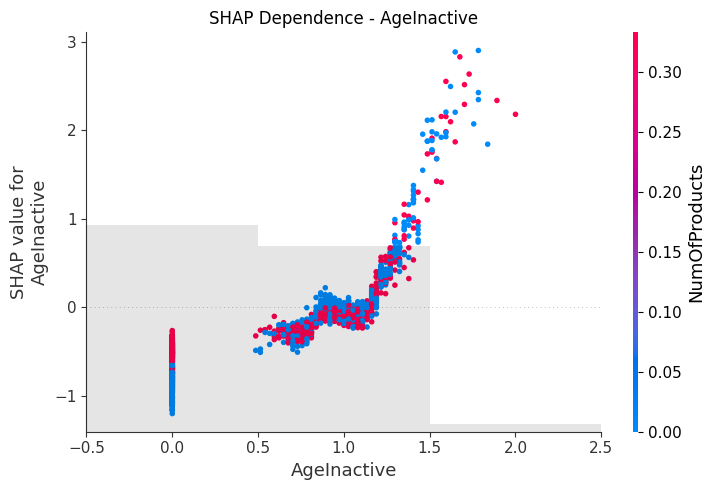

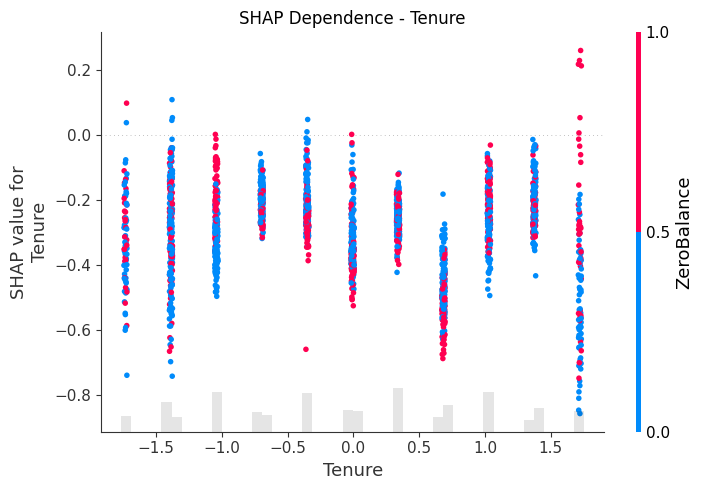

In [4]:
#SHAP dependence plots
top_features = importance_df['feature'].head(5).tolist()

for feature in top_features:
  shap.plots.scatter(shap_values[:, feature], color=shap_values, show=False)
  plt.title(f"SHAP Dependence - {feature}")
  plt.tight_layout()
  plt.show()

Each dependence plot shows one feature's SHAP value against its scaled range, showing the shape of its relationship with churn. ProductsRisk and NumOfProducts both show customers forming clusters rather than spreading continuously. AgeInactive,too,shows a similar but smoother pattern.

However, the SHAP values for Age make an inverted U shape, increasing churn through the early-mid ages, peaking in the middle-ages and declining for the oldest customers.

Tenure shows a weak and noisy effect in its range, with no directional trend.